# Exploratory Data Analysis (EDA)
This notebook explores the Twitter sentiment dataset, providing class distribution, review length analysis, and word clouds.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import os

plt.style.use('seaborn-v0_8-whitegrid')
os.makedirs('../reports', exist_ok=True)

# Load training data
df = pd.read_csv('../data/train.csv')
df.head()

,text,label,clean_text,label_text
0,"""QT @user In the original draft of the 7th boo...",2,qt original draft th book remus lupin survived...,positive
1,"""Ben Smith / Smith (concussion) remains out of...",1,ben smith smith concussion remains lineup thur...,neutral
2,Sorry bout the stream last night I crashed out...,1,sorry bout stream last night crashed tonight s...,neutral
3,Chase Headley's RBI double in the 8th inning o...,1,chase headleys rbi double th inning david pric...,neutral
4,@user Alciato: Bee will invest 150 million in ...,2,alciato bee invest million january another sum...,positive


### Class Distribution

C:\Users\Haji Shaikh\AppData\Local\Temp\ipykernel_11976\1852149857.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label_text', palette='viridis')


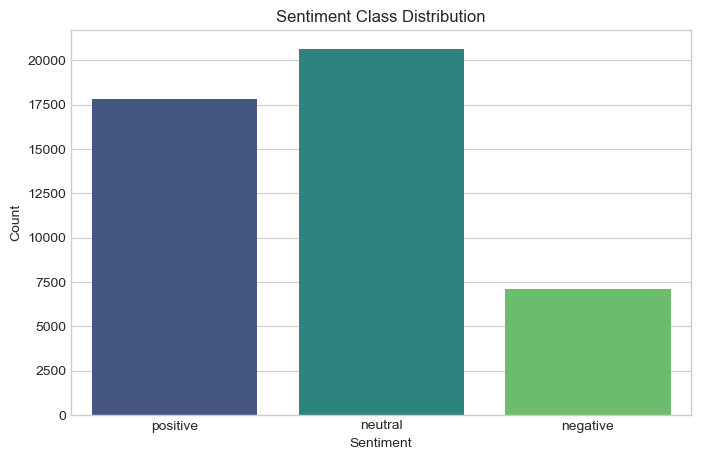

In [6]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='label_text', palette='viridis')
plt.title('Sentiment Class Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')

plt.savefig('../reports/class_distribution.png')
plt.show()

### Text Length Analysis

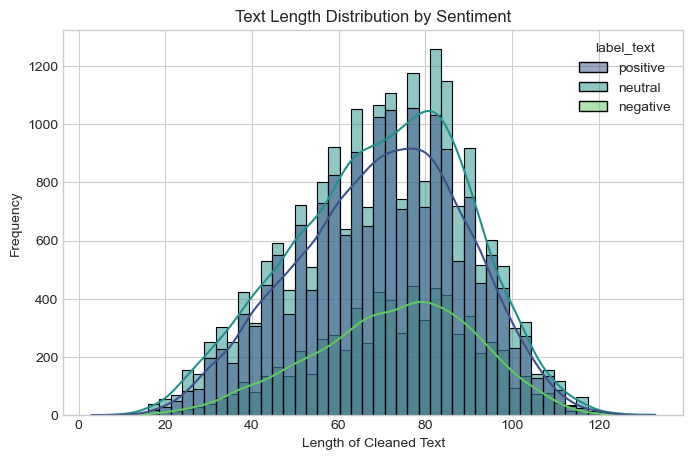

In [7]:
df['text_len'] = df['clean_text'].astype(str).apply(len)
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='text_len', hue='label_text', kde=True, bins=50, palette='viridis')
plt.title('Text Length Distribution by Sentiment')
plt.xlabel('Length of Cleaned Text')
plt.ylabel('Frequency')
plt.savefig('../reports/text_length_dist.png')
plt.show()

### Word Clouds

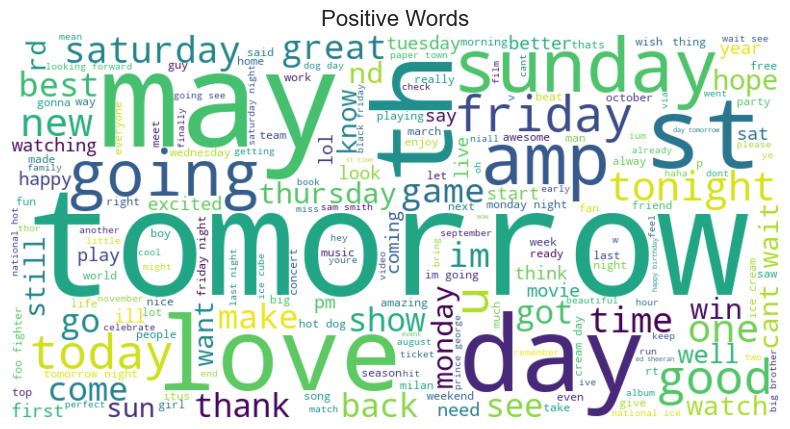

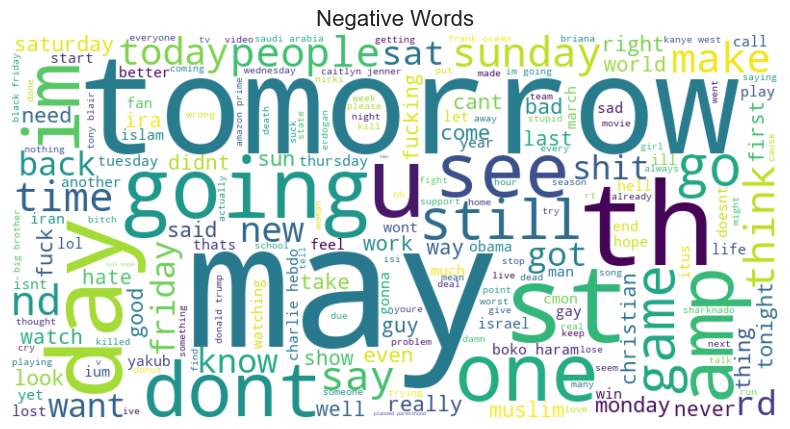

In [8]:
def generate_wordcloud(text, title, filename):
    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(title, fontsize=16)
    plt.axis('off')
    plt.savefig(f'../reports/{filename}')
    plt.show()

positive_text = ' '.join(df[df['label_text'] == 'positive']['clean_text'].astype(str).tolist())
negative_text = ' '.join(df[df['label_text'] == 'negative']['clean_text'].astype(str).tolist())

generate_wordcloud(positive_text, 'Positive Words', 'wordcloud_positive.png')
generate_wordcloud(negative_text, 'Negative Words', 'wordcloud_negative.png')

### N-Gram Analysis (Top 20 Bigrams)

C:\Users\Haji Shaikh\AppData\Local\Temp\ipykernel_11976\4210804039.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_ngrams, x='count', y='ngram', palette='viridis')


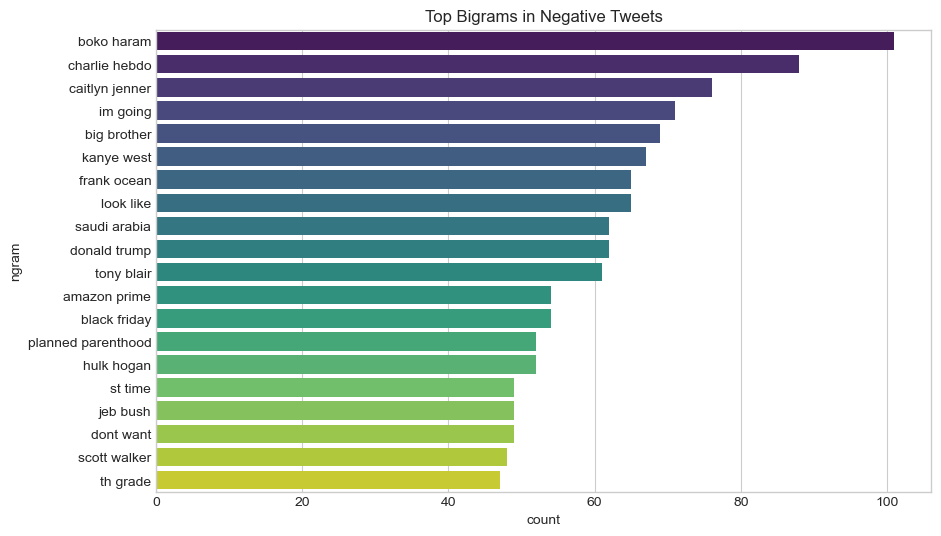

In [9]:
from sklearn.feature_extraction.text import CountVectorizer

def plot_top_ngrams(corpus, title, n=2):
    vec = CountVectorizer(ngram_range=(n, n)).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)[:20]
    
    df_ngrams = pd.DataFrame(words_freq, columns=['ngram', 'count'])
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_ngrams, x='count', y='ngram', palette='viridis')
    plt.title(title)
    plt.savefig(f'../reports/top_{n}grams_{title.replace(" ", "_").lower()}.png')
    plt.show()

plot_top_ngrams(df[df['label_text'] == 'negative']['clean_text'].dropna(), 'Top Bigrams in Negative Tweets', n=2)